20-patient files: {'k': './data/1Hz_Delta125/20Patients/20patients_k-anonymity-data-2025-08-12 15_00_33.csv', 'l': './data/1Hz_Delta125/20Patients/20patients_l-diversity-data-as-joinbyfield-2025-08-12 15_00_43.csv', 'il': './data/1Hz_Delta125/20Patients/20patients_Information Loss-data-2025-08-12 15_01_25.csv', 'lat': './data/1Hz_Delta125/20Patients/20patients_Latency Comparison-data-as-joinbyfield-2025-08-12 15_00_18.csv'}
100-patient files: {'k': './data/1Hz_Delta125/100Patients/100patients_k-anonymity-data-as-joinbyfield-2025-08-12 15_45_18.csv', 'l': './data/1Hz_Delta125/100Patients/100patients_l-diversity-data-as-joinbyfield-2025-08-12 15_45_28.csv', 'il': './data/1Hz_Delta125/100Patients/100patients_Information Loss-data-2025-08-12 15_45_36.csv', 'lat': './data/1Hz_Delta125/100Patients/100patients_Latency Comparison-data-2025-08-12 15_45_04.csv'}


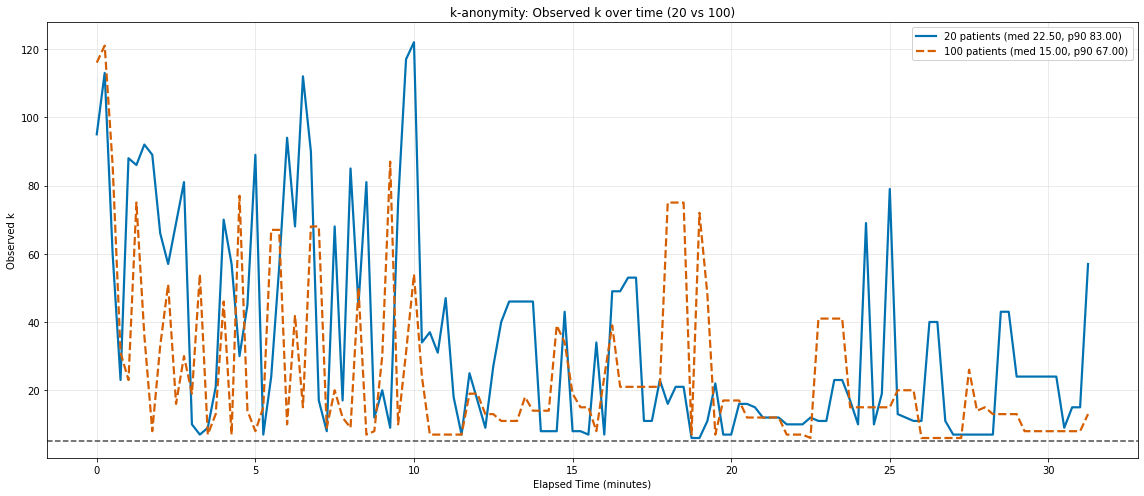

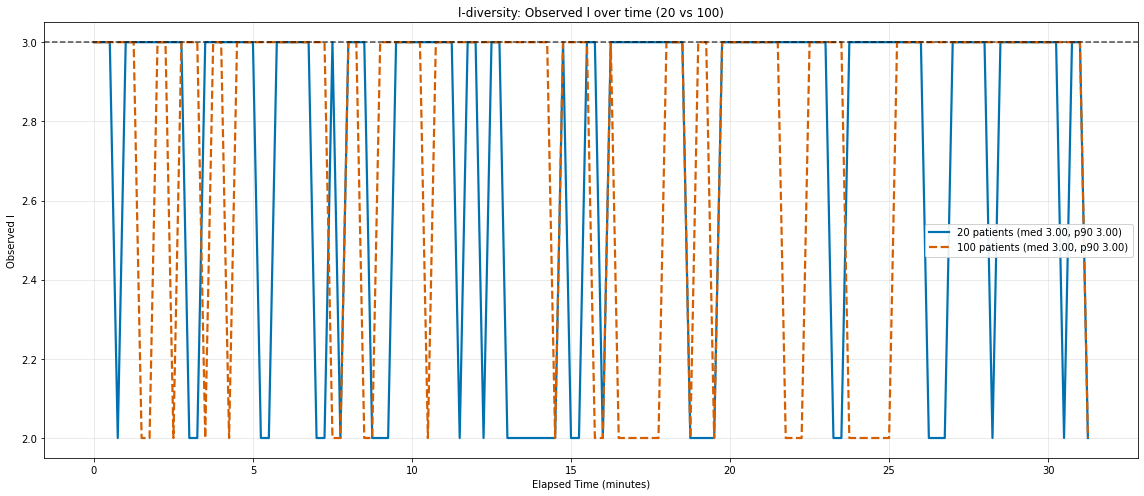

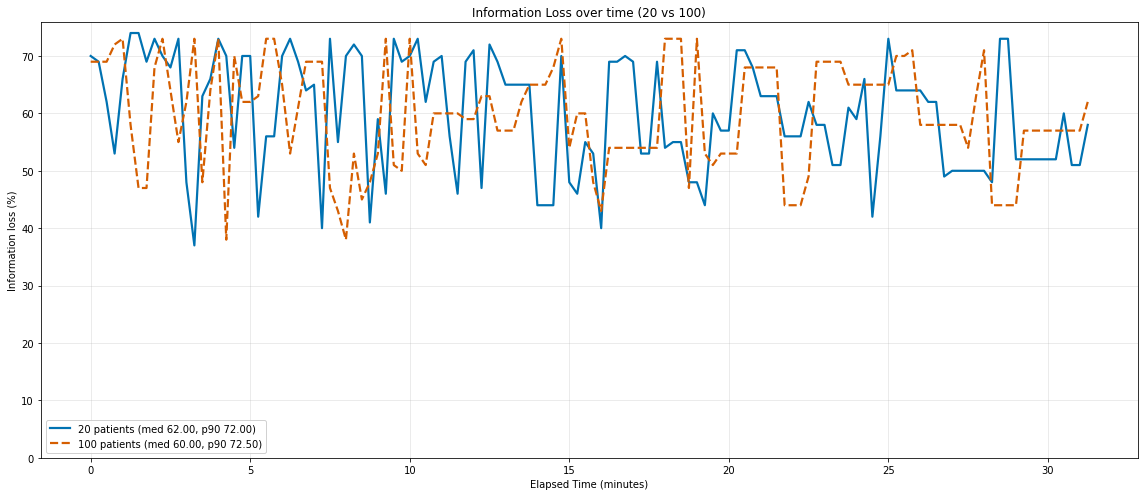

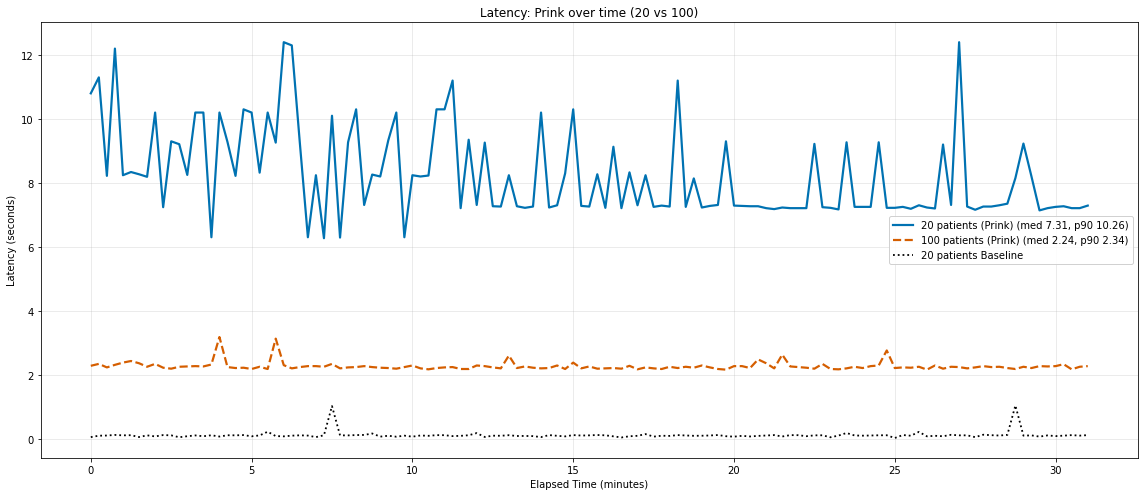

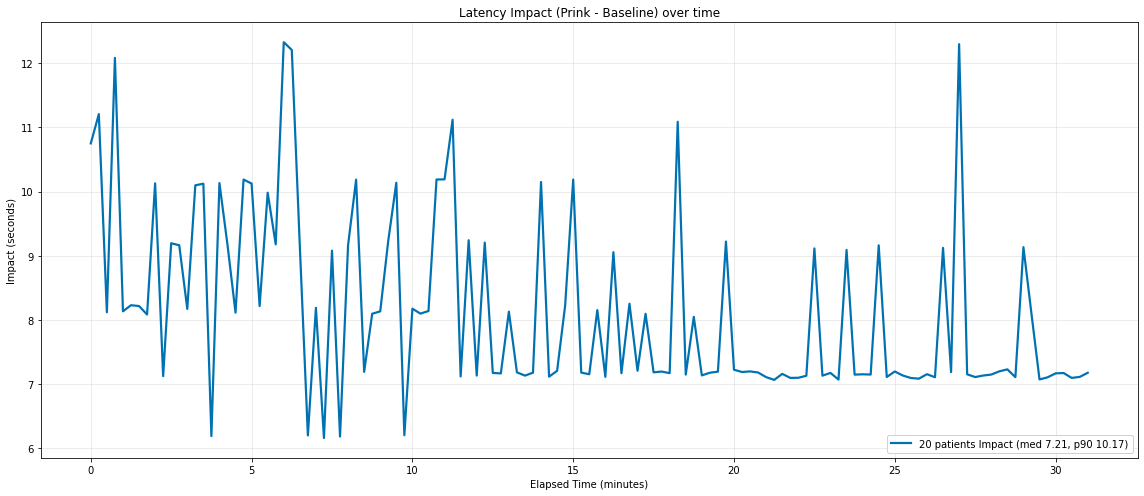

In [1]:
# === Joint plots for 20 vs 100 patients across four metrics ===
# Set these to your folders:
DIR_20 = "./data/1Hz_Delta125/20Patients"
DIR_100 = "./data/1Hz_Delta125/100Patients"

import os, re, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.colors as mcolors

# -------- Color-blind friendly palette (Okabe–Ito), no markers --------
COL_20 = '#0072B2'  # blue
COL_100 = '#D55E00' # vermillion
COL_BASELINE = '#000000'
STYLE_20 = '-'      # solid
STYLE_100 = '--'    # dashed

# -------- Small utilities --------
def _pick(cols, *names):
    norm = {c.lower().strip(): c for c in cols}
    for cand in names:
        c = norm.get(cand.lower().strip())
        if c: return c
    return None

def _elapsed_minutes(series):
    s = series.astype(str).str.strip()
    ts = pd.to_datetime(s, errors="coerce")
    if ts.notna().mean() > 0.8:
        return (ts - ts.iloc[0]).dt.total_seconds() / 60.0
    td = pd.to_timedelta(s, errors="coerce")
    if td.notna().mean() > 0.8:
        return td.dt.total_seconds() / 60.0
    # numeric fallback (assume minutes unless very large → seconds)
    vals = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    if pd.notna(vals.max()) and float(vals.max()) > 1000:
        vals = vals / 60.0
    return vals

def _to_seconds(series):
    s = series.astype(str).str.strip()
    has_colon = s.str.contains(":")
    out = pd.Series(index=s.index, dtype="float64")
    if has_colon.any():
        td = pd.to_timedelta(s[has_colon], errors="coerce")
        out.loc[has_colon] = td.dt.total_seconds()
    rest = s[~has_colon]
    ex = rest.str.extract(r'^\s*([-+]?\d+(?:[.,]\d+)?)(?:\s*([A-Za-z]+))?\s*$')
    num = pd.to_numeric(ex[0].str.replace(",", ".", regex=False), errors="coerce")
    unit = ex[1].str.lower().fillna("")
    factor = pd.Series(1.0, index=rest.index)
    factor[unit.isin(["ms","msec","millisecond","milliseconds"])] = 1/1000.0
    factor[unit.isin(["s","sec","secs","second","seconds",""])] = 1.0
    factor[unit.isin(["m","min","mins","minute","minutes"])] = 60.0
    out.loc[rest.index] = num * factor
    missing = out.isna()
    if missing.any():
        out.loc[missing] = pd.to_numeric(rest[missing].str.replace(",", ".", regex=False), errors="coerce")
    return out

def _to_percent_points(series):
    s = series.astype(str).str.strip()
    s = s.str.replace("%", "", regex=False)
    s = pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
    # assume 0..100 if max<=100 else already fraction
    if s.max(skipna=True) is not None and s.max(skipna=True) <= 1.0:
        s = s * 100.0
    return s

def _read_csv(path):
    return pd.read_csv(path)

def _common_window(dfs, xcol="Elapsed Minutes"):
    mins = []; maxs = []
    for df in dfs:
        x = df[xcol].dropna()
        if len(x):
            mins.append(float(x.min())); maxs.append(float(x.max()))
    if not mins or not maxs: return None, None
    return max(mins), min(maxs)

def _apply_window(df, start, end, xcol="Elapsed Minutes"):
    if start is None or end is None: return df
    m = (df[xcol] >= start) & (df[xcol] <= end)
    return df.loc[m].copy()

def _parse_defined(df, *names):
    c = _pick(df.columns, *names)
    if c is None: return None
    vals = pd.to_numeric(df[c], errors="coerce")
    uniq = vals.dropna().unique()
    if len(uniq) == 0: return None
    # if varies, use median as reference
    return float(np.median(uniq))

# -------- Find files in each folder --------
def _find_one(folder, key_words):
    # look for a csv whose filename contains ALL key_words (case-insensitive)
    cand = []
    for fp in glob.glob(os.path.join(folder, "*.csv")):
        name = os.path.basename(fp).lower()
        if all(kw.lower() in name for kw in key_words):
            cand.append(fp)
    return sorted(cand)[:1][0] if cand else None

files_20 = {
    "k": _find_one(DIR_20, ["k-anonymity"]),
    "l": _find_one(DIR_20, ["l-diversity"]),
    "il": _find_one(DIR_20, ["information", "loss"]),
    "lat": _find_one(DIR_20, ["latency", "comparison"]),
}
files_100 = {
    "k": _find_one(DIR_100, ["k-anonymity"]),
    "l": _find_one(DIR_100, ["l-diversity"]),
    "il": _find_one(DIR_100, ["information", "loss"]),
    "lat": _find_one(DIR_100, ["latency", "comparison"]),
}
print("20-patient files:", files_20)
print("100-patient files:", files_100)

# -------- Load & normalize per metric --------
def load_k(path):
    df = _read_csv(path)
    tcol = _pick(df.columns, "Time", "Timestamp", "Datetime")
    ocol = _pick(df.columns, "Observed k", "Observed_k", "ObservedK")
    if tcol is None or ocol is None:
        raise ValueError(f"k file missing columns: {path}")
    out = pd.DataFrame({
        "Elapsed Minutes": _elapsed_minutes(df[tcol]).astype(float),
        "Observed": pd.to_numeric(df[ocol], errors="coerce").astype(float)
    })
    # defined may be missing (e.g., 20-patients)
    defined = _parse_defined(df, "Defined k", "Defined_k", "DefinedK")
    return out, defined

def load_l(path):
    df = _read_csv(path)
    tcol = _pick(df.columns, "Time", "Timestamp", "Datetime")
    ocol = _pick(df.columns, "Observed l", "Observed_l", "ObservedL")
    if tcol is None or ocol is None:
        raise ValueError(f"l file missing columns: {path}")
    out = pd.DataFrame({
        "Elapsed Minutes": _elapsed_minutes(df[tcol]).astype(float),
        "Observed": pd.to_numeric(df[ocol], errors="coerce").astype(float)
    })
    defined = _parse_defined(df, "Defined l", "Defined_l", "DefinedL")
    return out, defined

def load_il(path):
    df = _read_csv(path)
    tcol = _pick(df.columns, "Time", "Timestamp", "Datetime")
    pcol = _pick(df.columns, "Information Loss", "information loss", "infromation loss")
    if tcol is None or pcol is None:
        raise ValueError(f"Information Loss file missing columns: {path}")
    out = pd.DataFrame({
        "Elapsed Minutes": _elapsed_minutes(df[tcol]).astype(float),
        "InfoLossPct": _to_percent_points(df[pcol]).astype(float)
    })
    return out

def load_lat(path):
    df = _read_csv(path)
    tcol = _pick(df.columns, "Time", "Timestamp", "Datetime")
    pcol = _pick(df.columns, "Prink Latency", "Prink_Latency", "PrinkLatency")
    bcol = _pick(df.columns, "Baseline Latency", "Baseline_Latency", "BaselineLatency")
    if tcol is None or pcol is None:
        raise ValueError(f"Latency file missing Time/Prink columns: {path}")
    out = pd.DataFrame({
        "Elapsed Minutes": _elapsed_minutes(df[tcol]).astype(float),
        "Prink_s": _to_seconds(df[pcol]).astype(float)
    })
    if bcol is not None:
        out["Baseline_s"] = _to_seconds(df[bcol]).astype(float)
        out["Impact_s"] = out["Prink_s"] - out["Baseline_s"]
    return out

# -------- Joint plotting helpers --------
def _legend_stats(y):
    y = pd.to_numeric(y, errors="coerce").dropna()
    if y.empty: return ""
    return f"(med {y.median():.2f}, p90 {y.quantile(0.9):.2f})"

def _plot_overlay_xy(ax, x1, y1, label1, x2, y2, label2, ylab, title):
    ax.plot(x1, y1, linewidth=2.2, color=COL_20, linestyle=STYLE_20, label=f"{label1} {_legend_stats(y1)}")
    ax.plot(x2, y2, linewidth=2.2, color=COL_100, linestyle=STYLE_100, label=f"{label2} {_legend_stats(y2)}")
    ax.set_title(title)
    ax.set_xlabel("Elapsed Time (minutes)")
    ax.set_ylabel(ylab)
    ax.grid(True, alpha=0.3)
    ax.legend(framealpha=0.9)

def _draw_defined(ax, val, label):
    if val is None: return
    ax.axhline(val, color=COL_BASELINE, linestyle="--", linewidth=1.5, alpha=0.7, label=label)

def _apples_window(*dfs):
    start, end = _common_window(list(dfs))
    if start is None or end is None or end <= start:
        return dfs
    return tuple(_apply_window(df, start, end) for df in dfs)

# ===================== PLOTS =====================

# 1) k-anonymity
if files_20["k"] and files_100["k"]:
    dfk20, defk20 = load_k(files_20["k"])
    dfk100, defk100 = load_k(files_100["k"])
    dfk20, dfk100 = _apples_window(dfk20, dfk100)
    fig, ax = plt.subplots(figsize=(16,7))
    _plot_overlay_xy(ax,
                     dfk20["Elapsed Minutes"], dfk20["Observed"], "20 patients",
                     dfk100["Elapsed Minutes"], dfk100["Observed"], "100 patients",
                     ylab="Observed k", title="k-anonymity: Observed k over time (20 vs 100)")
    # target (prefer a defined k if present; if one side missing, use the other)
    target_k = defk20 if defk20 is not None else defk100
    _draw_defined(ax, target_k, f"Defined k={int(target_k) if target_k is not None else '?'}")
    plt.tight_layout(); plt.show()
else:
    print("Missing k-anonymity file in one of the folders.")

# 2) l-diversity
if files_20["l"] and files_100["l"]:
    dfl20, defl20 = load_l(files_20["l"])
    dfl100, defl100 = load_l(files_100["l"])
    dfl20, dfl100 = _apples_window(dfl20, dfl100)
    fig, ax = plt.subplots(figsize=(16,7))
    _plot_overlay_xy(ax,
                     dfl20["Elapsed Minutes"], dfl20["Observed"], "20 patients",
                     dfl100["Elapsed Minutes"], dfl100["Observed"], "100 patients",
                     ylab="Observed l", title="l-diversity: Observed l over time (20 vs 100)")
    target_l = defl20 if defl20 is not None else defl100
    _draw_defined(ax, target_l, f"Defined l={int(target_l) if target_l is not None else '?'}")
    plt.tight_layout(); plt.show()
else:
    print("Missing l-diversity file in one of the folders.")

# 3) Information Loss (%)
if files_20["il"] and files_100["il"]:
    dfi20 = load_il(files_20["il"])
    dfi100 = load_il(files_100["il"])
    dfi20, dfi100 = _apples_window(dfi20, dfi100)
    fig, ax = plt.subplots(figsize=(16,7))
    _plot_overlay_xy(ax,
                     dfi20["Elapsed Minutes"], dfi20["InfoLossPct"], "20 patients",
                     dfi100["Elapsed Minutes"], dfi100["InfoLossPct"], "100 patients",
                     ylab="Information loss (%)", title="Information Loss over time (20 vs 100)")
    ax.set_ylim(bottom=0)  # percentages
    plt.tight_layout(); plt.show()
else:
    print("Missing Information Loss file in one of the folders.")

# 4) Latency Comparison
if files_20["lat"] and files_100["lat"]:
    dfl20 = load_lat(files_20["lat"])
    dfl100 = load_lat(files_100["lat"])
    dfl20, dfl100 = _apples_window(dfl20, dfl100)

    # (a) Prink latency overlay (seconds)
    fig, ax = plt.subplots(figsize=(16,7))
    _plot_overlay_xy(ax,
                     dfl20["Elapsed Minutes"], dfl20["Prink_s"], "20 patients (Prink)",
                     dfl100["Elapsed Minutes"], dfl100["Prink_s"], "100 patients (Prink)",
                     ylab="Latency (seconds)", title="Latency: Prink over time (20 vs 100)")
    # Show baseline(s) if available
    if "Baseline_s" in dfl20.columns:
        ax.plot(dfl20["Elapsed Minutes"], dfl20["Baseline_s"], color=COL_BASELINE, linestyle=":", linewidth=1.8, label="20 patients Baseline")
    if "Baseline_s" in dfl100.columns:
        ax.plot(dfl100["Elapsed Minutes"], dfl100["Baseline_s"], color=COL_BASELINE, linestyle="--", linewidth=1.2, alpha=0.6, label="100 patients Baseline")
    ax.legend(framealpha=0.9)
    plt.tight_layout(); plt.show()

    # (b) Latency Impact overlay (where available)
    if "Impact_s" in dfl20.columns or "Impact_s" in dfl100.columns:
        fig, ax = plt.subplots(figsize=(16,7))
        if "Impact_s" in dfl20.columns:
            ax.plot(dfl20["Elapsed Minutes"], dfl20["Impact_s"], color=COL_20, linestyle=STYLE_20, linewidth=2.2,
                    label=f"20 patients Impact {_legend_stats(dfl20['Impact_s'])}")
        if "Impact_s" in dfl100.columns:
            ax.plot(dfl100["Elapsed Minutes"], dfl100["Impact_s"], color=COL_100, linestyle=STYLE_100, linewidth=2.2,
                    label=f"100 patients Impact {_legend_stats(dfl100['Impact_s'])}")
        ax.set_title("Latency Impact (Prink - Baseline) over time")
        ax.set_xlabel("Elapsed Time (minutes)"); ax.set_ylabel("Impact (seconds)")
        ax.grid(True, alpha=0.3); ax.legend(framealpha=0.9)
        plt.tight_layout(); plt.show()
else:
    print("Missing Latency Comparison file in one of the folders.")